In [1]:
import pandas as pd
from itertools import combinations
import math
import numpy as np
import statistics
from itertools import permutations
from bioinfokit import analys, visuz
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint
from matplotlib_venn import venn2
import copy
import random
from vst_function import *
from stattools.resampling import PermutationTest
from pyranges import PyRanges

pd.read_table('/Users/luciabazan/Downloads/metadata_1000genomes.tsv')

,Sample name,Sex,Biosample ID,Population code,Population name,Superpopulation code,Superpopulation name,Population elastic ID,Data collections
0,HG00459,male,SAME125269,CHS,Southern Han Chinese,EAS,East Asian Ancestry,CHS,"1000 Genomes 30x on GRCh38,1000 Genomes phase ..."
1,HG00473,female,SAME123338,CHS,Southern Han Chinese,EAS,East Asian Ancestry,CHS,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
2,HG00478,male,SAME123335,CHS,Southern Han Chinese,EAS,East Asian Ancestry,CHS,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
3,HG00480,male,SAME124617,CHS,Southern Han Chinese,EAS,East Asian Ancestry,CHS,"1000 Genomes 30x on GRCh38,1000 Genomes phase ..."
4,HG00500,male,SAME123363,CHS,Southern Han Chinese,EAS,East Asian Ancestry,CHS,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
...,...,...,...,...,...,...,...,...,...
3197,NA21117,male,SAME124185,GIH,Gujarati,SAS,South Asian Ancestry,GIH,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
3198,NA21124,male,SAME124024,GIH,Gujarati,SAS,South Asian Ancestry,GIH,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
3199,NA21129,male,SAME124023,GIH,Gujarati,SAS,South Asian Ancestry,GIH,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
3200,NA21143,female,SAME123359,GIH,Gujarati,SAS,South Asian Ancestry,GIH,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."


# Data processing

- This notebook contains the preprocessing pipeline for both assemblies(GRCh37 and T2T-CHM13) as sames as code for table 1, figure 1 and 6. 
- Files used and saved it are located in /data folder 

## GRCh38

- These calls were obtained from HPRC in https://s3-us-west-2.amazonaws.com/human-pangenomics/index.html?prefix=submissions/759B21AD-0ED8-4640-A433-7C92A57EA3D3--UW_EEE_SV_Calls/GRCh38/
- We merge the calls using HandyCNV package in R 

In [2]:
#anotation = pd.read_table('/Users/luciabazan/Downloads/biosample_table.tsv')
anotation = pd.read_table('/Users/luciabazan/Downloads/metadata_1000genomes.tsv')

ids_hg19 = pd.DataFrame()
ids_hg19['Sample'] = anotation['Sample name']
ids_hg19['Region'] = anotation['Superpopulation code']

chm13 = pd.read_table('/Users/luciabazan/Documents/GitHub/cnv_sgdp/call_cnvr_grch38_hprc/individual_cnv_cnvr.txt')
#change to df when using telomeres and centromeres filtration


chm13 = chm13.dropna()

## Keeping only samples that are on old cnvs 
chm13 = chm13.merge(ids_hg19, right_on=['Sample'], left_on=['Sample_ID'])


#
chm13.columns = ['Chromosome', 'Start', 'End', 'CNVR_ID', 'Sample', 'CNV_start', 'CNV_end', 'CNV_Value','Length', 'Sample','Region']

#chm13 = pd.read_csv('../data/chm13_gene_regions.csv', index_col=0)
chm13['Lenght'] = chm13['End'] - chm13['Start']
chm13

## Kepp CNVs less than 1Mb and greater than 1Kb
chm13 = chm13[chm13['Lenght'] < 1000000] # 2000000
chm13 = chm13[chm13['Lenght'] > 1000]


##
### Plotiing distribution

deletions = chm13[chm13 ['CNV_Value'] < 2]
deletions['type'] = 'Deletion'
duplications = chm13[chm13['CNV_Value'] > 2]
duplications['type'] = 'Duplication'


distribution = pd.concat([deletions,duplications])

chm13.columns = ['Chromosome','Start','End','CNVR_ID,','Sample_ID','CNV_Start','CNV_End','CNV_Value','Length','Sample','Region', 'Lenght']

#change to df when using telomeres and centromeres filtration
final_cnv = chm13.pivot_table(index=["Chromosome", "Start", "End"], 
                    columns='Sample', 
                    values='CNV_Value',
                        fill_value=2).reset_index()


final_cnv['Length'] = final_cnv['End'] - final_cnv['Start']
data_grch37 = final_cnv


# Saving file for Vst and PCA 
data_grch37.to_csv('../data/input_grch38_hprc.csv')
data_grch37

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/2516857309.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deletions['type'] = 'Deletion'
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/2516857309.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplications['type'] = 'Duplication'


Sample,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,1,65562.0,66618.0,2.0,1.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,1.000000,2.0,1.0,2.0,1.0,1056.0
1,1,96603.0,98682.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2079.0
2,1,126241.0,707779.0,1.5,1.5,1.0,1.60,1.5,1.714286,1.625,...,1.5,2.0,0.800000,1.0,1.333333,1.0,1.5,2.0,1.5,581538.0
3,1,713327.0,714478.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,1151.0
4,1,725043.0,728380.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,3337.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10977,9,138081484.0,138087539.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,0.0,2.0,2.0,6055.0
10978,9,138125044.0,138139226.0,1.0,2.0,1.0,2.00,1.5,2.000000,1.000,...,1.5,1.0,2.000000,1.0,1.000000,2.0,2.0,2.0,1.0,14182.0
10979,9,138183904.0,138186463.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2559.0
10980,9,138190962.0,138196916.0,0.0,3.0,1.5,1.50,1.0,0.000000,0.000,...,0.0,1.5,1.500000,3.0,0.000000,0.0,0.0,1.0,0.0,5954.0


In [3]:
deletions = data_grch37[(data_grch37[data_grch37.columns[3:-1]]<3).all(axis=1)]
deletions['TYPE'] = 'deletion'

duplications = data_grch37[(data_grch37[data_grch37.columns[3:-1]]>1).all(axis=1)]
duplications['TYPE'] = 'duplication'

data_grch37_input_figure= pd.concat([deletions,duplications])
data_grch37_input_figure['Length'] = data_grch37_input_figure['End'] - data_grch37_input_figure['Start']

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/1550035052.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deletions['TYPE'] = 'deletion'
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/1550035052.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplications['TYPE'] = 'duplication'


## T2T-CHM13 

- CNVs calls where obtained from HPRC in https://s3-us-west-2.amazonaws.com/human-pangenomics/index.html?prefix=submissions/759B21AD-0ED8-4640-A433-7C92A57EA3D3--UW_EEE_SV_Calls/CHM13/
- We merge the calls using HandyCNV package in R 


In [4]:
chm13 = pd.read_table('/Users/luciabazan/Documents/GitHub/cnv_sgdp/call_cnvr_t2t_hprc/individual_cnv_cnvr.txt')
#change to df when using telomeres and centromeres filtration


chm13 = chm13.dropna()

## Keeping only samples that are on old cnvs 
chm13 = chm13.merge(ids_hg19, right_on=['Sample'], left_on=['Sample_ID'])


#
chm13.columns = ['Chromosome', 'Start', 'End', 'CNVR_ID', 'Sample', 'CNV_start', 'CNV_end', 'CNV_Value','Length', 'Sample','Region']

#chm13 = pd.read_csv('../data/chm13_gene_regions.csv', index_col=0)
chm13['Lenght'] = chm13['End'] - chm13['Start']
chm13

## Kepp CNVs less than 1Mb and greater than 1Kb
chm13 = chm13[chm13['Lenght'] < 1000000] # 2000000
chm13 = chm13[chm13['Lenght'] > 1000]


##
### Plotiing distribution

deletions = chm13[chm13 ['CNV_Value'] < 2]
deletions['type'] = 'Deletion'
duplications = chm13[chm13['CNV_Value'] > 2]
duplications['type'] = 'Duplication'


distribution = pd.concat([deletions,duplications])

chm13.columns = ['Chromosome','Start','End','CNVR_ID,','Sample_ID','CNV_Start','CNV_End','CNV_Value','Length','Sample','Region', 'Lenght']

#change to df when using telomeres and centromeres filtration
final_cnv = chm13.pivot_table(index=["Chromosome", "Start", "End"], 
                    columns='Sample', 
                    values='CNV_Value',
                        fill_value=2).reset_index()

final_cnv['Length'] = final_cnv['End'] - final_cnv['Start']

data_chm13  = final_cnv


# Saving file for Vst and PCA 
data_chm13.to_csv('../data/input_t2t_hprc.csv')
data_chm13 

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/335520766.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deletions['type'] = 'Deletion'
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/335520766.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplications['type'] = 'Duplication'


Sample,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,1,736.0,3272.0,1.0,2.0,2.000000,1.0,2.000000,1.0,1.0,...,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2536.0
1,1,24123.0,26129.0,1.0,2.0,2.000000,1.5,1.000000,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,2.0,2006.0
2,1,34674.0,134000.0,2.0,2.0,1.333333,1.0,1.444444,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,99326.0
3,1,139890.0,140991.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1101.0
4,1,151553.0,153659.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12729,9,150493245.0,150494904.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1659.0
12730,9,150539980.0,150547555.0,1.0,2.0,2.000000,2.0,1.000000,2.0,0.0,...,1.0,2.0,2.0,2.0,2.0,0.0,2.0,1.0,0.0,7575.0
12731,9,150547891.0,150549071.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1180.0
12732,9,150549961.0,150551513.0,2.0,2.0,2.000000,0.0,1.000000,2.0,2.0,...,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1552.0


In [5]:
data_chm13['Chromosome'] = 'chr' + data_chm13['Chromosome'].astype(str)

In [6]:
deletions = data_chm13[(data_chm13[data_chm13.columns[4:-1]]<=2).all(axis=1)]
deletions['TYPE'] = 'deletion'

duplications = data_chm13[(data_chm13[data_chm13.columns[4:-1]]>=2).all(axis=1)]
duplications['TYPE'] = 'duplication'

data_chm13_input_figure = pd.concat([deletions,duplications])
data_chm13_input_figure['Length'] = data_chm13_input_figure['End'] - data_chm13_input_figure['Start']

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/3609987877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deletions['TYPE'] = 'deletion'
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/3609987877.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  duplications['TYPE'] = 'duplication'


<h1> Figure 1 

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/3099196110.py:16: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim([0, 1000000])
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/3099196110.py:27: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim([0, 1000000])


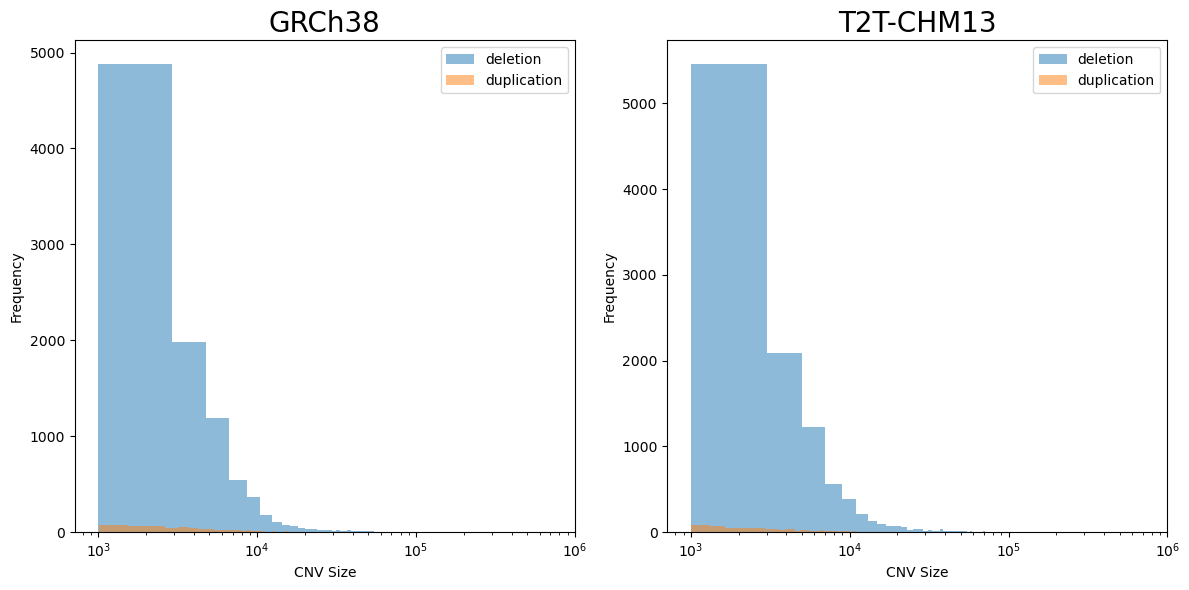

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2,  sharex=True) #sharey=True,
#ax1.set_ylim([0, 50000])

fig.set_size_inches(12, 6, forward=True)

ax1.set_title('GRCh38', size=20)


df = data_grch37_input_figure.groupby(['TYPE'])['Length']


df.plot(kind='hist',stacked=True, bins=500, logx=True, ax=ax1, alpha=0.5, legend=True) # alpha for transparency
ax1.set_xlabel('CNV Size', size=10)
ax1.set_ylabel('Frequency', size = 10)

ax1.set_xlim([0, 1000000])
#fig.suptitle
ax2.set_title('T2T-CHM13', size=20)



df = data_chm13_input_figure.groupby(['TYPE'])['Length']

df.plot(kind='hist',stacked=True, bins=500,logx=True, ax=ax2, alpha=0.5, legend=True) # alpha for transparency
ax2.set_xlabel('CNV Size', size = 10)
#ax2.set_ylabel(' ')
ax2.set_xlim([0, 1000000])
fig.tight_layout() 

plt.savefig('../plots/distribution_t2t_and_grch38_hprc.png', transparent=True)

plt.show()

<h2> Table 1
<h3> T2T-CHM13

In [8]:
## Anotations
t2t_genes = pd.read_csv('../data/annotation_files/T2T-chm13-catLiftOffGenes.csv')
t2t_genes.columns = ['Chromosome', 'Start', 'End', 'name', 'score', 'strand',
       'thickStart', 'thickEnd', 'reserved', 'blockCount', 'blockSizes',
       'chromStarts', 'name2', 'cdsStartStat', 'cdsEndStat', 'exonFrames',
       'txId', 'type', 'geneName', 'geneType', 'sourceGene',
       'sourceTranscript', 'alignmentId', 'alternativeSourceTranscripts',
       'Paralogy', 'UnfilteredParalogy', 'collapsedGeneIds',
       'collapsedGeneNames', 'frameshift', 'exonAnnotationSupport',
       'intronAnnotationSupport', 'transcriptClass', 'transcriptModes',
       'validStart', 'validStop', 'properOrf', 'extra_paralog']
#t2t_genes['Chromosome'] = t2t_genes['Chromosome'].str.replace('chr', '')
t2t_genes = PyRanges(t2t_genes)

t2t_telomeres = pd.read_csv('../data/annotation_files/chm13v2.0_telomere.bed', sep='\t', names=['Chromosome','Start', 'End'])
#t2t_telomeres['Chromosome'] = t2t_telomeres['Chromosome'].str.replace('chr', '')
t2t_sds = pd.read_csv('../data/annotation_files/chm13v2.0_SD.full.bed', sep='\t')
t2t_sds = t2t_sds[['#chr1', 'start1', 'end1']]
#t2t_sds['#chr1'] = t2t_sds['#chr1'].str.replace('chr', '')

t2t_sds.columns =['Chromosome','Start','End']

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/2246860587.py:2: DtypeWarning: Columns (23,36) have mixed types. Specify dtype option on import or set low_memory=False.
  t2t_genes = pd.read_csv('../data/annotation_files/T2T-chm13-catLiftOffGenes.csv')


In [9]:
data_chm13_ranges = PyRanges(data_chm13)
data_chm13_ranges

Sample,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,chr1,736,3272,1.0,2.0,2.000000,1.0,2.000000,1.0,1.0,...,2.0,2.0,2.00,1.0,2.0,2.000000,2.0,2.0,2.0,2536.0
1,chr1,24123,26129,1.0,2.0,2.000000,1.5,1.000000,2.0,2.0,...,1.0,2.0,2.00,2.0,1.0,1.000000,2.0,1.0,2.0,2006.0
2,chr1,34674,134000,2.0,2.0,1.333333,1.0,1.444444,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,0.0,2.0,99326.0
3,chr1,139890,140991,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,2.0,2.0,1101.0
4,chr1,151553,153659,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,2.0,2.0,2106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12729,chr22,51136085,51158037,2.0,2.0,1.000000,1.0,1.000000,0.0,2.0,...,2.0,1.0,1.00,2.0,1.0,1.666667,1.5,1.0,1.0,21952.0
12730,chr22,51193635,51195108,2.0,2.0,2.000000,2.0,1.000000,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,2.0,2.0,1473.0
12731,chr22,51196249,51198088,2.0,2.0,2.000000,2.0,2.000000,2.0,1.5,...,2.0,2.0,1.25,2.0,1.0,2.000000,2.0,1.0,2.0,1839.0
12732,chr22,51313529,51314814,1.0,1.0,2.000000,2.0,2.000000,1.0,2.0,...,2.0,1.0,1.00,0.5,2.0,1.000000,0.0,1.0,1.0,1285.0


In [10]:
# Genes
coordinates_genes = data_chm13_ranges.nearest(t2t_genes)
coordinates_genes = coordinates_genes.as_df()
coordinates_genes = coordinates_genes[coordinates_genes['Distance'] <1 ]

In [11]:
# Telomeres
#t2t_telomeres['Chromosome'] = t2t_telomeres['Chromosome'].str.replace('chr', '')
t2t_telomeres = PyRanges(t2t_telomeres)

coordinates_telomeres = data_chm13_ranges.nearest(t2t_telomeres)
coordinates_telomeres = coordinates_telomeres.as_df()
coordinates_telomeres = coordinates_telomeres[coordinates_telomeres['Distance'] <1]

In [12]:
# SDs
t2t_sds = PyRanges(t2t_sds)
coordinates_sds = data_chm13_ranges.nearest(t2t_sds)
coordinates_sds = coordinates_sds.as_df()
coordinates_sds = coordinates_sds[coordinates_sds['Distance'] <1 ]

In [13]:
data_chm13.iloc[:,2:207].columns[1:]

Index(['HG00097', 'HG00099', 'HG00126', 'HG00128', 'HG00133', 'HG00140',
       'HG00146', 'HG00232', 'HG00235', 'HG00253',
       ...
       'NA19185', 'NA19240', 'NA19338', 'NA19391', 'NA19443', 'NA19468',
       'NA19682', 'NA19700', 'NA19776', 'NA19835'],
      dtype='object', name='Sample', length=204)

In [14]:
## Deletions
t2t_deletions = data_chm13[(data_chm13[data_chm13.iloc[:,2:207].columns[1:]]<=2).all(axis=1)]
t2t_deletions.replace(2, np.nan, inplace=True)
t2t_mean_individual_deletions = t2t_deletions.iloc[:,3:207].mean()
t2t_deletions.replace(np.nan,2, inplace=True)
t2t_deletions = PyRanges(t2t_deletions)
t2t_deletions

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/371933360.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t2t_deletions.replace(2, np.nan, inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/371933360.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t2t_deletions.replace(np.nan,2, inplace=True)


Sample,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,chr1,736,3272,1.0,2.0,2.000000,1.0,2.000000,1.000000,1.0,...,2.000000,2.000000,2.000000,1.0,2.000,2.0,2.0,2.000000,2.000000,2536.0
1,chr1,34674,134000,2.0,2.0,1.333333,1.0,1.444444,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,0.000000,2.000000,99326.0
2,chr1,139890,140991,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,2.000000,2.000000,1101.0
3,chr1,151553,153659,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,2.000000,2.000000,2106.0
4,chr1,156352,344468,0.5,1.0,1.000000,0.5,1.090909,0.333333,0.5,...,0.142857,0.333333,1.142857,0.0,0.625,0.8,0.5,1.142857,1.222222,188116.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11009,chr22,50942385,50944034,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,2.000000,2.000000,1649.0
11010,chr22,51004619,51005728,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,2.000000,2.000000,1109.0
11011,chr22,51193635,51195108,2.0,2.0,2.000000,2.0,1.000000,2.000000,2.0,...,2.000000,2.000000,2.000000,2.0,2.000,2.0,2.0,2.000000,2.000000,1473.0
11012,chr22,51313529,51314814,1.0,1.0,2.000000,2.0,2.000000,1.000000,2.0,...,2.000000,1.000000,1.000000,0.5,2.000,1.0,0.0,1.000000,1.000000,1285.0


In [15]:
deletions_t2t_coordinates_genes = t2t_deletions.nearest(t2t_genes)
deletions_t2t_coordinates_genes = deletions_t2t_coordinates_genes.as_df()
deletions_t2t_coordinates_genes = deletions_t2t_coordinates_genes[deletions_t2t_coordinates_genes['Distance'] <1 ]
deletions_t2t_coordinates_genes.iloc[:,3:207]

,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,HG00232,HG00235,HG00253,...,NA19185,NA19240,NA19338,NA19391,NA19443,NA19468,NA19682,NA19700,NA19776,NA19835
0,2.0,2.0,1.333333,1.0,1.444444,2.000000,2.0,1.000,1.500000,2.000000,...,1.333333,2.0,2.000000,1.000000,1.0,0.500000,2.000000,1.571429,2.000000,1.000000
1,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,2.000,2.000000,2.000000,...,2.000000,2.0,2.000000,2.000000,2.0,2.000000,2.000000,2.000000,2.000000,2.000000
2,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,2.000,2.000000,2.000000,...,1.000000,2.0,2.000000,1.000000,2.0,1.000000,2.000000,2.000000,2.000000,2.000000
3,0.5,1.0,1.000000,0.5,1.090909,0.333333,0.5,0.625,1.461538,0.833333,...,0.857143,1.0,0.571429,0.833333,1.0,1.000000,0.428571,0.833333,0.333333,1.166667
4,0.0,2.0,2.000000,2.0,0.000000,2.000000,1.0,2.000,2.000000,2.000000,...,1.000000,2.0,2.000000,2.000000,2.0,2.000000,2.000000,2.000000,2.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10722,2.0,1.0,1.000000,2.0,2.000000,2.000000,2.0,2.000,1.000000,2.000000,...,0.000000,1.0,2.000000,2.000000,1.0,1.000000,2.000000,0.000000,2.000000,2.000000
10723,1.0,0.5,2.000000,1.0,2.000000,2.000000,2.0,2.000,1.000000,2.000000,...,1.000000,0.0,0.000000,1.000000,0.5,1.000000,1.000000,2.000000,1.000000,0.000000
10724,2.0,2.0,2.000000,2.0,2.000000,2.000000,2.0,2.000,2.000000,2.000000,...,1.000000,1.0,2.000000,1.000000,1.0,0.666667,1.000000,2.000000,2.000000,1.000000
10725,2.0,2.0,2.000000,2.0,1.000000,2.000000,2.0,2.000,2.000000,2.000000,...,2.000000,2.0,2.000000,2.000000,2.0,2.000000,2.000000,2.000000,2.000000,2.000000


In [16]:
#### Genes 
deletions_t2t_coordinates_genes = t2t_deletions.nearest(t2t_genes)
deletions_t2t_coordinates_genes = deletions_t2t_coordinates_genes.as_df()
deletions_t2t_coordinates_genes = deletions_t2t_coordinates_genes[deletions_t2t_coordinates_genes['Distance'] <1 ]
# Mean CN 
deletions_t2t_coordinates_genes.replace(2, np.nan, inplace=True)
deletions_t2t_mean_individual_genes= deletions_t2t_coordinates_genes.iloc[:,3:207].mean()
deletions_t2t_coordinates_genes.replace(np.nan,2, inplace=True)


#### Telomeres
deletions_t2t_coordinates_telomeres = t2t_deletions.nearest(t2t_telomeres)
deletions_t2t_coordinates_telomeres = deletions_t2t_coordinates_telomeres.as_df()
deletions_t2t_coordinates_telomeres = deletions_t2t_coordinates_telomeres[deletions_t2t_coordinates_telomeres['Distance'] <1 ]
deletions_t2t_coordinates_telomeres
# Mean CN 
deletions_t2t_coordinates_telomeres.replace(2, np.nan, inplace=True)
deletions_t2t_mean_individual_telomeres= deletions_t2t_coordinates_telomeres.iloc[:,3:207].mean()
deletions_t2t_coordinates_telomeres.replace(np.nan,2, inplace=True)


#### SDs 
deletions_t2t_coordinates_sds = t2t_deletions.nearest(t2t_sds)
deletions_t2t_coordinates_sds = deletions_t2t_coordinates_sds.as_df()
deletions_t2t_coordinates_sds = deletions_t2t_coordinates_sds[deletions_t2t_coordinates_sds['Distance'] <1 ]
# Mean CN 
deletions_t2t_coordinates_sds.replace(2, np.nan, inplace=True)
deletions_t2t_mean_individual_sds= deletions_t2t_coordinates_sds.iloc[:,3:207].mean()
deletions_t2t_coordinates_sds.replace(np.nan,2, inplace=True)

deletions_t2t_mean_individual_sds.mean()

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/74500179.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  deletions_t2t_coordinates_genes.replace(np.nan,2, inplace=True)


0.8552799712901767

In [17]:
####### duplications 
t2t_duplications = data_chm13[(data_chm13[data_chm13.iloc[:,3:207].columns[1:]]>=2).all(axis=1)]
t2t_duplications.replace(2, np.nan, inplace=True)
t2t_mean_individual_duplications = t2t_duplications.iloc[:,3:207].mean()
t2t_duplications.replace(np.nan,2, inplace=True)
t2t_duplications  = PyRanges(t2t_duplications)
len(t2t_duplications)

t2t_mean_individual_duplications.mean()

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/864469744.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t2t_duplications.replace(2, np.nan, inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/864469744.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t2t_duplications.replace(np.nan,2, inplace=True)


3.3575525177436942

In [18]:
#### Genes 
duplications_t2t_coordinates_genes = t2t_duplications.nearest(t2t_genes)
duplications_t2t_coordinates_genes = duplications_t2t_coordinates_genes.as_df()
duplications_t2t_coordinates_genes = duplications_t2t_coordinates_genes[duplications_t2t_coordinates_genes['Distance'] <1 ]
# Mean CN 
duplications_t2t_coordinates_genes.replace(2, np.nan, inplace=True)
duplications_t2t_mean_individual_genes= duplications_t2t_coordinates_genes.iloc[:,3:207].mean()
duplications_t2t_coordinates_genes.replace(np.nan,2, inplace=True)


#### Telomeres
duplications_t2t_coordinates_telomeres = t2t_duplications.nearest(t2t_telomeres)
duplications_t2t_coordinates_telomeres = duplications_t2t_coordinates_telomeres.as_df()
duplications_t2t_coordinates_telomeres = duplications_t2t_coordinates_telomeres[duplications_t2t_coordinates_telomeres['Distance'] <1 ]
duplications_t2t_coordinates_telomeres
# Mean CN 
duplications_t2t_coordinates_telomeres.replace(2, np.nan, inplace=True)
duplications_t2t_mean_individual_telomeres= duplications_t2t_coordinates_telomeres.iloc[:,3:207].mean()
duplications_t2t_coordinates_telomeres.replace(np.nan,2, inplace=True)


#### SDs 
duplications_t2t_coordinates_sds = t2t_duplications.nearest(t2t_sds)
duplications_t2t_coordinates_sds = duplications_t2t_coordinates_sds.as_df()
duplications_t2t_coordinates_sds = duplications_t2t_coordinates_sds[duplications_t2t_coordinates_sds['Distance'] <1 ]
# Mean CN 
duplications_t2t_coordinates_sds.replace(2, np.nan, inplace=True)
duplications_t2t_mean_individual_sds= duplications_t2t_coordinates_sds.iloc[:,3:207].mean()
duplications_t2t_coordinates_sds.replace(np.nan,2, inplace=True)

duplications_t2t_mean_individual_sds.mean()


/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/3751681795.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  duplications_t2t_coordinates_genes.replace(np.nan,2, inplace=True)


3.1295045045045042

<h2> GRCh38

In [19]:
data_grch37_ranges = PyRanges(data_grch37)

## Anotations
grch37_genes = pd.read_csv('/Users/luciabazan/Downloads/grch38_genes')
grch37_telomeres = pd.read_csv('/Users/luciabazan/Downloads/grch38_telomeres')
grch37_sds = pd.read_csv('/Users/luciabazan/Downloads/grch38_sds')
#grch37_sds = grch37_sds[['#chr1', 'start1', 'end1']]


grch37_telomeres.columns =['#"bin','Chromosome','Start','End', 'ix','n', 'size','type','bridge']
#t2t_sds
grch37_genes.columns = ['#"bin"', 'name', 'Chromosome', 'strand', 'Start', 'End', 'cdsStart',
       'cdsEnd', 'exonCount', 'exonStarts', 'exonEnds', 'score', 'name2',
       'cdsStartStat', 'cdsEndStat', 'exonFrames'] 
grch37_telomeres = grch37_telomeres[grch37_telomeres['type'] == 'telomere']
grch37_sds.columns = ['#"bin"', 'Chromosome', 'Start', 'End', 'name', 'score', 'strand',
       'otherChrom', 'otherStart', 'otherEnd', 'otherSize', 'uid',
       'posBasesHit', 'testResult', 'verdict', 'chits', 'ccov', 'alignfile',
       'alignL', 'indelN', 'indelS', 'alignB', 'matchB', 'mismatchB',
       'transitionsB', 'transversionsB', 'fracMatch', 'fracMatchIndel', 'jcK',
       'k2K']

data_grch37#iloc[:,2:207].columns[1:]
#grch37_deletions#.iloc[:,2:207]


Sample,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,1,65562.0,66618.0,2.0,1.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,1.000000,2.0,1.0,2.0,1.0,1056.0
1,1,96603.0,98682.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2079.0
2,1,126241.0,707779.0,1.5,1.5,1.0,1.60,1.5,1.714286,1.625,...,1.5,2.0,0.800000,1.0,1.333333,1.0,1.5,2.0,1.5,581538.0
3,1,713327.0,714478.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,1151.0
4,1,725043.0,728380.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,3337.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10977,9,138081484.0,138087539.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,0.0,2.0,2.0,6055.0
10978,9,138125044.0,138139226.0,1.0,2.0,1.0,2.00,1.5,2.000000,1.000,...,1.5,1.0,2.000000,1.0,1.000000,2.0,2.0,2.0,1.0,14182.0
10979,9,138183904.0,138186463.0,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,...,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2559.0
10980,9,138190962.0,138196916.0,0.0,3.0,1.5,1.50,1.0,0.000000,0.000,...,0.0,1.5,1.500000,3.0,0.000000,0.0,0.0,1.0,0.0,5954.0


In [39]:
## Deletions 
grch37_deletions = data_grch37[(data_grch37[data_grch37.iloc[:,2:207].columns[1:]]<=2).all(axis=1)]
grch37_deletions.replace(2, np.nan, inplace=True)
grch37_mean_individual_deletions = grch37_deletions.iloc[:,3:207].mean()
grch37_deletions.replace(np.nan,2, inplace=True)
grch37_deletions = PyRanges(grch37_deletions)

# duplications 
grch37_duplications = data_grch37[(data_grch37[data_grch37.iloc[:,2:207].columns[1:]]>=2).all(axis=1)]
grch37_duplications.replace(2, np.nan, inplace=True)
grch37_mean_individual_duplications = grch37_duplications.iloc[:,3:207].mean()
grch37_duplications.replace(np.nan,2, inplace=True)
#grch37_duplications  = PyRanges(grch37_duplications)
grch37_mean_individual_duplications.mean()

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/3896657600.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grch37_deletions.replace(2, np.nan, inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/3896657600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grch37_deletions.replace(np.nan,2, inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_85382/3896657600.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

7.621316702036037

In [40]:
grch37_duplications.iloc[:,3:207]

Sample,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,HG00232,HG00235,HG00253,...,NA19185,NA19240,NA19338,NA19391,NA19443,NA19468,NA19682,NA19700,NA19776,NA19835
23,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
34,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
44,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
48,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
58,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10884,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
10901,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
10926,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
10927,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [21]:
grch37_genes['Chromosome'] = grch37_genes['Chromosome'].str.replace('chr', '')
grch37_genes_coordinates = PyRanges(grch37_genes)

In [22]:
grch37_coordinates_genes = data_grch37_ranges.nearest(grch37_genes_coordinates)
grch37_coordinates_genes = grch37_coordinates_genes.as_df()
grch37_coordinates_genes = grch37_coordinates_genes[grch37_coordinates_genes['Distance'] <1 ]
len(grch37_coordinates_genes)

5889

In [23]:
grch37_telomeres['Chromosome'] = grch37_telomeres['Chromosome'].str.replace('chr', '')
grch37_telomeres = PyRanges(grch37_telomeres)
grch37_coordinates_telomeres = data_grch37_ranges.nearest(grch37_telomeres)
grch37_coordinates_telomeres = grch37_coordinates_telomeres.as_df()
grch37_coordinates_telomeres = grch37_coordinates_telomeres[grch37_coordinates_telomeres['Distance'] <1 ]

In [24]:
grch37_sds['Chromosome'] = grch37_sds['Chromosome'].str.replace('chr', '')
grch37_sds = PyRanges(grch37_sds)
grch37_coordinates_sds = data_grch37_ranges.nearest(grch37_sds)
grch37_coordinates_sds = grch37_coordinates_sds.as_df()
grch37_coordinates_sds = grch37_coordinates_sds[grch37_coordinates_sds['Distance'] <1 ]

In [25]:
### Deletions 
#### Genes 
deletions_grch37_coordinates_genes = grch37_deletions.nearest(grch37_genes_coordinates)
deletions_grch37_coordinates_genes = deletions_grch37_coordinates_genes.as_df()
deletions_grch37_coordinates_genes = deletions_grch37_coordinates_genes[deletions_grch37_coordinates_genes['Distance'] <1 ]
# Mean CN 
deletions_grch37_coordinates_genes.replace(2, np.nan, inplace=True)
deletions_grch37_mean_individual_genes= deletions_grch37_coordinates_genes.iloc[:,3:207].mean()
deletions_grch37_coordinates_genes.replace(np.nan,2, inplace=True)


### Telomeres
deletions_grch37_coordinates_telomeres = grch37_deletions.nearest(grch37_telomeres)
deletions_grch37_coordinates_telomeres = deletions_grch37_coordinates_telomeres.as_df()
deletions_grch37_coordinates_telomeres = deletions_grch37_coordinates_telomeres[deletions_grch37_coordinates_telomeres['Distance'] <1 ]
deletions_grch37_coordinates_telomeres
# Mean CN 
deletions_grch37_coordinates_telomeres.replace(2, np.nan, inplace=True)
deletions_grch37_mean_individual_telomeres= deletions_grch37_coordinates_telomeres.iloc[:,3:207].mean()
deletions_grch37_coordinates_telomeres.replace(np.nan,2, inplace=True)


#### SDs 
deletions_grch37_coordinates_sds = grch37_deletions.nearest(grch37_sds)
deletions_grch37_coordinates_sds = deletions_grch37_coordinates_sds.as_df()
deletions_grch37_coordinates_sds = deletions_grch37_coordinates_sds[deletions_grch37_coordinates_sds['Distance'] <1 ]
# Mean CN 
deletions_grch37_coordinates_sds.replace(2, np.nan, inplace=True)
deletions_grch37_mean_individual_sds= deletions_grch37_coordinates_sds.iloc[:,3:207].mean()
deletions_grch37_coordinates_sds.replace(np.nan,2, inplace=True)



In [26]:
deletions_grch37_coordinates_genes.iloc[:,3:207]

,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,HG00232,HG00235,HG00253,...,NA19185,NA19240,NA19338,NA19391,NA19443,NA19468,NA19682,NA19700,NA19776,NA19835
0,2.000000,2.0,2.00,2.000000,2.0,2.000000,2.000000,2.000,2.0,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.0,2.000000,2.000000,2.000000,2.00
1,0.000000,0.0,0.00,0.000000,0.0,0.000000,0.000000,0.000,0.0,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,1.000000,0.000000,0.00
2,2.000000,2.0,2.00,2.000000,2.0,2.000000,2.000000,2.000,2.0,2.000000,...,1.000000,2.000000,2.000000,1.000000,2.000000,2.0,2.000000,2.000000,2.000000,2.00
3,0.777778,0.0,1.00,0.333333,0.9,0.333333,0.625000,0.625,1.1,1.000000,...,1.285714,0.666667,0.916667,1.142857,1.222222,1.0,0.777778,1.111111,0.285714,1.00
4,2.000000,1.0,2.00,1.000000,2.0,1.000000,2.000000,2.000,2.0,2.000000,...,1.000000,1.000000,1.000000,2.000000,2.000000,2.0,1.000000,2.000000,1.666667,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9739,2.000000,2.0,2.00,2.000000,2.0,2.000000,2.000000,2.000,2.0,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.0,2.000000,2.000000,2.000000,2.00
9740,0.250000,0.0,0.75,1.000000,1.0,0.400000,1.333333,0.000,1.0,0.600000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.5,1.500000,1.000000,0.400000,0.25
9741,2.000000,2.0,2.00,2.000000,2.0,2.000000,2.000000,2.000,2.0,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.0,2.000000,2.000000,2.000000,2.00
9742,2.000000,2.0,2.00,2.000000,2.0,2.000000,2.000000,2.000,2.0,2.000000,...,1.000000,1.000000,2.000000,1.000000,1.000000,0.5,1.000000,2.000000,2.000000,1.00


In [27]:
### Duplications
#### Genes 
duplications_grch37_coordinates_genes = grch37_duplications.nearest(grch37_genes_coordinates)
duplications_grch37_coordinates_genes = duplications_grch37_coordinates_genes.as_df()
duplications_grch37_coordinates_genes = duplications_grch37_coordinates_genes[duplications_grch37_coordinates_genes['Distance'] <1 ]
# Mean CN 
duplications_grch37_coordinates_genes.replace(2, np.nan, inplace=True)
duplications_grch37_mean_individual_genes= duplications_grch37_coordinates_genes.iloc[:,3:207].mean()
duplications_grch37_coordinates_genes.replace(np.nan,2, inplace=True)


#### Telomeres
duplications_grch37_coordinates_telomeres = grch37_duplications.nearest(grch37_telomeres)
duplications_grch37_coordinates_telomeres = duplications_grch37_coordinates_telomeres.as_df()
duplications_grch37_coordinates_telomeres = duplications_grch37_coordinates_telomeres[duplications_grch37_coordinates_telomeres['Distance'] <1 ]
# Mean CN 
duplications_grch37_coordinates_telomeres.replace(2, np.nan, inplace=True)
duplications_grch37_mean_individual_telomeres= duplications_grch37_coordinates_telomeres.iloc[:,3:207].mean()
duplications_grch37_coordinates_telomeres.replace(np.nan,2, inplace=True)


#### SDs 
duplications_grch37_coordinates_sds = grch37_duplications.nearest(grch37_sds)
duplications_grch37_coordinates_sds = duplications_grch37_coordinates_sds.as_df()
duplications_grch37_coordinates_sds = duplications_grch37_coordinates_sds[duplications_grch37_coordinates_sds['Distance'] <1 ]
# Mean CN 
duplications_grch37_coordinates_sds.replace(2, np.nan, inplace=True)
duplications_grch37_mean_individual_sds= duplications_grch37_coordinates_sds.iloc[:,3:207].mean()
duplications_grch37_coordinates_sds.replace(np.nan,2, inplace=True)

In [33]:
duplications_grch37_coordinates_sds#.iloc[:,3:207]

,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,alignB,matchB,mismatchB,transitionsB,transversionsB,fracMatch,fracMatchIndel,jcK,k2K,Distance
0,1,16713838,16727354,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,31730,31536,194,131,63.0,0.993886,0.993135,0.006139,0.006142,0
1,1,16895421,16896457,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,51437,50219,1218,746,472.0,0.976321,0.974351,0.024061,0.024096,0
2,1,21430785,21433674,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,3392,3352,40,29,11.0,0.988208,0.987044,0.011886,0.011903,0
3,1,21981728,21983195,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,22757,22050,707,480,227.0,0.968933,0.966173,0.031729,0.031823,0
4,1,47041380,47060031,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,1474,1399,75,52,23.0,0.949118,0.940820,0.052690,0.052976,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,22,10679412,10686505,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,173261,172314,947,530,417.0,0.994534,0.993674,0.005486,0.005487,0
1066,22,10758987,10771251,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,25328,24850,478,321,157.0,0.981128,0.978655,0.019114,0.019146,0
1067,22,11313665,11315142,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,107410,99894,7516,4414,3102.0,0.930025,0.926428,0.073458,0.073742,0
1068,22,16611346,16614747,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,5258,5122,136,82,54.0,0.974135,0.970811,0.026322,0.026361,0


In [30]:
d = {'Data': ['GRCh38', '  Genes','  Telomeres','  SDs','T2T-CHM13', '  Genes','  Telomeres','  SDs'], 
     'Total': [len(data_grch37), 
               len(grch37_coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()), 
               len(grch37_coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
               len(grch37_coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates()),  
               len(data_chm13), 
               len(coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()), 
               len(coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
               len(coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates())], 
     'Mean size(Bp)':[data_grch37['Length'].mean().round(), 
                      round(grch37_coordinates_genes['Length'].mean()), 
                      grch37_coordinates_telomeres['Length'].mean(), 
                      round(grch37_coordinates_sds['Length'].mean()), 
                      round(data_chm13['Length'].mean()),
                      round(coordinates_genes['Length'].mean()),
                      round(coordinates_telomeres['Length'].mean()), 
                      round(coordinates_sds['Length'].mean())],
          'S.D. ()':[round(data_grch37['Length'].std()), 
                      round(grch37_coordinates_genes['Length'].std()), 
                      grch37_coordinates_telomeres['Length'].std(), 
                      round(grch37_coordinates_sds['Length'].std()), 
                      round(data_chm13['Length'].std()),
                      round(coordinates_genes['Length'].std()),
                      round(coordinates_telomeres['Length'].std()), 
                      round(coordinates_sds['Length'].std())],
     'Deletions':[len(grch37_deletions), 
                  len(deletions_grch37_coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()),
                  len(deletions_grch37_coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
                  len(deletions_grch37_coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates()), 
                  len(t2t_deletions), 
                  len(deletions_t2t_coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()),
                  len(deletions_t2t_coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
                  len(deletions_t2t_coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates()), ], 
     'Duplications':[len(grch37_duplications), 
                     len(duplications_grch37_coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()),
                     len(duplications_grch37_coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
                     len(duplications_grch37_coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates()),
                     len(t2t_duplications), 
                     len(duplications_t2t_coordinates_genes[['Chromosome','Start', 'End']].drop_duplicates()),
                     len(duplications_t2t_coordinates_telomeres[['Chromosome','Start', 'End']].drop_duplicates()), 
                     len(duplications_t2t_coordinates_sds[['Chromosome','Start', 'End']].drop_duplicates()) ],
     'Mean CN Deletions' :[grch37_mean_individual_deletions.mean(),
                           deletions_grch37_mean_individual_genes.mean(),
                           deletions_grch37_mean_individual_telomeres.mean(),
                           deletions_grch37_mean_individual_sds.mean(),
                           t2t_mean_individual_deletions.mean(),
                           deletions_t2t_mean_individual_genes.mean(),
                           deletions_t2t_mean_individual_telomeres.mean(),
                           deletions_t2t_mean_individual_sds.mean()],
     'Mean CN Duplications' :[grch37_mean_individual_duplications.mean(),
                           duplications_grch37_mean_individual_genes.mean(),
                           duplications_grch37_mean_individual_telomeres.mean(),
                           duplications_grch37_mean_individual_sds.mean(),
                           t2t_mean_individual_duplications.mean(),
                           duplications_t2t_mean_individual_genes.mean(),
                           duplications_t2t_mean_individual_telomeres.mean(),
                           duplications_t2t_mean_individual_sds.mean()],
    
    }
df = pd.DataFrame(data=d)
df#.to_csv('../data/table1_cnv_calls_between_assemblies.csv')

,Data,Total,Mean size(Bp),S.D. (),Deletions,Duplications,Mean CN Deletions,Mean CN Duplications
0,GRCh38,10982,9747.0,40324.0,9819,1080,0.703655,7.621317
1,Genes,5889,12930.0,53017.0,5196,566,0.709707,3.730508
2,Telomeres,0,NaN,NaN,0,0,NaN,NaN
3,SDs,1248,28651.0,91870.0,952,133,0.801572,5.168997
4,T2T-CHM13,12734,12146.0,50117.0,11014,1306,0.764244,3.357553
5,Genes,7039,15264.0,60178.0,6024,663,0.755364,3.501536
6,Telomeres,42,20620.0,48509.0,21,8,1.173989,2.941176
7,SDs,2132,30012.0,100270.0,1520,160,0.855280,3.129505


<h2> Figure 6 (Moved to Vst-PCA notebook)

In [32]:
grch37_mean_individual_duplications

Sample
HG00097    3.583333
HG00099         NaN
HG00126    3.653846
HG00128    7.486111
HG00133    3.375000
             ...   
NA19468    6.134615
NA19682    5.030303
NA19700    3.529412
NA19776    3.555556
NA19835    4.083333
Length: 204, dtype: float64